# 01 — Ensemble EBM 생성 (multi-method) + Diversity 분석

여러 randomization methods 를 조합해서 ensemble 을 만든다. 모든 resolved 값은
멤버의 `config.json` 에 저장되어 bit-exact 재현 가능.

## 0. 설정 — 조합 / 스케일 / GPU

### 사용 가능한 methods (registry)

| name | 역할 | 멤버별 파라미터 |
|---|---|---|
| `Subsample` | D_c 의 일부만 context 로. 매 멤버가 **독립 랜덤** sub-sample | `ratio = SUB_RATIO` |
| `Distance` | hypercube 반지름 α | `DIST_MODE` 로 선택 (아래) |
| `CornerNoise` | surrogate negative 에 Gaussian 노이즈 | `noise_std ∈ [0.1, 2.0]` |
| `NumFakeCorners` | 2^d vertex 중 n 개만 랜덤 선택 | `n_corners ∈ [4, min(2^d, 64)]` |

### Distance 모드 (`DIST_MODE`)
- `'fixed'` : 전 멤버가 **같은 값** `DIST_FIXED` 사용 → α 를 고정하고 다른 랜덤 소스(Subsample 등)만의 영향 확인용.
- `'sweep'` : 멤버 k 의 α 를 `linspace(DIST_RANGE[0], DIST_RANGE[1], K)[k]` 로 차례대로 할당.
  - 예: `DIST_RANGE=[1,10], K=10` → 멤버 0→1, 1→2, …, 9→10
- `'random'`: `DIST_RANGE` 에서 uniform 랜덤.

### 각 설정 파라미터
- `METHODS_ACTIVE`: 활성화할 methods 리스트 — 넣으면 켜짐
- `K`: ensemble 멤버 수 (= 독립 EBM 개수, K≥2)
- `SUB_RATIO`: 각 멤버가 쓸 D_c 비율 (0 < ratio ≤ 1)
- `DIST_MODE` / `DIST_FIXED` / `DIST_RANGE`: 위 Distance 모드 표 참고
- `DATASET`, `N_REAL`: openml 이름, subsample 크기
- `CLASSES`: fit 할 class 번호
- `SEED`: 재현성 seed
- `GPUS`: 사용할 GPU 번호 리스트

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
os.chdir('/home/work/JooKyung/TabEBM')

import sys, json, subprocess, time, warnings
from concurrent.futures import ThreadPoolExecutor
warnings.filterwarnings('ignore')
sys.path.insert(0, 'experiments'); sys.path.insert(0, 'src')

import numpy as np, pandas as pd, torch
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from ensemble_ebm import rebuild_ebm, evaluate_energy
from ensemble_methods import METHODS
from tabebm.canary import attach_canary, verify_canary

pd.set_option('display.width', 220); pd.set_option('display.precision', 4)

# ======================================================================
#  조합 설정
# ======================================================================
# 사용 가능: 'Subsample', 'Distance', 'CornerNoise', 'NumFakeCorners'
METHODS_ACTIVE = ['Distance']   # ← 원하는 조합 선택

K              = 10              # ensemble 멤버 수
SUB_RATIO      = 0.25            # 각 멤버의 sub-sample 비율 (0 < ratio ≤ 1)

# --- Distance 모드 선택 ---------------------------------------------------
# 'fixed' : 모든 멤버 동일 값(DIST_FIXED).  다른 랜덤 소스(Subsample 등)만의 영향 확인용.
# 'sweep' : 멤버 k → linspace(DIST_RANGE[0], DIST_RANGE[1], K)[k] (차례대로).
# 'random': DIST_RANGE 에서 uniform 랜덤.
DIST_MODE      = 'fixed'         # 'fixed' | 'sweep' | 'random'
DIST_FIXED     = 6.0             # mode='fixed' 일 때 전 멤버가 쓸 α
DIST_RANGE     = [1.0, 10.0]     # mode='sweep' 또는 'random' 일 때 사용
# -------------------------------------------------------------------------

DATASET        = 'stock'
N_REAL         = 100
CLASSES        = [0, 1]
SEED           = 42
GPUS           = [0, 1, 2, 3]

# 모드에 맞춰 Distance 파라미터 구성
_dist_params = {'mode': DIST_MODE}
if DIST_MODE == 'fixed':
    _dist_params['value'] = DIST_FIXED
else:
    _dist_params['dist_range'] = DIST_RANGE

METHOD_PARAMS_OVERRIDE = {
    'Subsample': {'ratio': SUB_RATIO},
    'Distance':  _dist_params,
    # 'CornerNoise':    {'noise_range': [0.0, 1.0]},
    # 'NumFakeCorners': {'n_range':     [4, 16]},
}

REUSE_LATEST = False
# ======================================================================

print(f'등록된 methods (registry): {list(METHODS)}')
for m in METHODS_ACTIVE:
    assert m in METHODS, f'Unknown method: {m}. 등록된: {list(METHODS)}'
assert 0.0 < SUB_RATIO <= 1.0, f'SUB_RATIO must be in (0, 1], got {SUB_RATIO}'
assert DIST_MODE in ('fixed', 'sweep', 'random'), f'bad DIST_MODE {DIST_MODE}'
if DIST_MODE == 'fixed':
    assert DIST_FIXED > 0, f'DIST_FIXED must be > 0, got {DIST_FIXED}'
    print(f'Distance mode=fixed  value={DIST_FIXED}  (전 멤버 동일)')
else:
    assert len(DIST_RANGE) == 2 and 0 < DIST_RANGE[0] < DIST_RANGE[1], f'bad DIST_RANGE {DIST_RANGE}'
    if DIST_MODE == 'sweep':
        grid = np.linspace(DIST_RANGE[0], DIST_RANGE[1], K)
        print(f'Distance mode=sweep  grid (멤버 0..{K-1}): {grid.tolist()}')
    else:
        print(f'Distance mode=random  range={DIST_RANGE}')
print(f'Active: {METHODS_ACTIVE}')
print(f'K={K}  SUB_RATIO={SUB_RATIO}  seed={SEED}  classes={CLASSES}')


등록된 methods (registry): ['Subsample', 'Distance', 'CornerNoise', 'NumFakeCorners']
Distance mode=fixed  value=6.0  (전 멤버 동일)
Active: ['Distance']
K=10  SUB_RATIO=0.25  seed=42  classes=[0, 1]


## 1. Ensemble fit — timestamped 폴더 생성

In [2]:
EBM_ROOT = Path('experiments/ebms')

def find_latest_run(methods_active):
    tag = '-'.join(methods_active) + '_EBM'
    cand = sorted(p for p in EBM_ROOT.iterdir() if p.is_dir() and p.name.endswith(tag))
    return cand[-1] if cand else None

ENSEMBLE_ROOT = None
if REUSE_LATEST:
    prev = find_latest_run(METHODS_ACTIVE)
    if prev and all((prev / f'c{c}' / 'meta.json').exists() for c in CLASSES):
        ENSEMBLE_ROOT = prev
        print(f'Reusing: {ENSEMBLE_ROOT}')

if ENSEMBLE_ROOT is None:
    args = ['/home/work/miniconda3/envs/TabEBM/bin/python',
            'experiments/fit_ensemble_v2.py',
            '--dataset', DATASET, '--n_real', str(N_REAL),
            '--n_ebms', str(K),
            '--methods', *METHODS_ACTIVE,
            '--classes', *[str(c) for c in CLASSES],
            '--seed', str(SEED)]
    if METHOD_PARAMS_OVERRIDE:
        args += ['--method_params', json.dumps(METHOD_PARAMS_OVERRIDE)]
    t0 = time.time()
    r = subprocess.run(args, capture_output=True, text=True)
    if r.returncode != 0:
        print('STDOUT:', r.stdout[-1500:]); print('STDERR:', r.stderr[-1500:])
        raise RuntimeError('fit failed')
    for line in r.stdout.splitlines():
        if line.strip().startswith('Run root:'):
            ENSEMBLE_ROOT = Path(line.split('Run root:', 1)[1].strip())
            break
    assert ENSEMBLE_ROOT is not None
    print(f'Created run ({time.time()-t0:.1f}s): {ENSEMBLE_ROOT}')

print(f'\n>>> nb 02/03 의 ENSEMBLE_ROOT 에 복붙 <<<\n    {ENSEMBLE_ROOT}')

Created run (2.7s): experiments/ebms/20260417_201751_Distance_EBM

>>> nb 02/03 의 ENSEMBLE_ROOT 에 복붙 <<<
    experiments/ebms/20260417_201751_Distance_EBM


## 2. 멤버별 metadata preview

In [3]:
def load_member_configs(class_dir, K):
    rows = []
    for k in range(K):
        cfg = json.loads((class_dir / f'ebm_{k}' / 'config.json').read_text())
        row = {'k': k, 'seed': cfg.get('seed')}
        if 'method_distance' in cfg:         row['distance'] = cfg['method_distance']['neg_distance']
        if 'method_corner_noise' in cfg:     row['corner_noise_std'] = cfg['method_corner_noise']['noise_std']
        if 'method_num_fake_corners' in cfg: row['n_corners'] = cfg['method_num_fake_corners']['n_corners']
        if 'method_subsample' in cfg:        row['sub_ratio'] = cfg['method_subsample']['ratio']
        rows.append(row)
    return pd.DataFrame(rows)

for c in CLASSES:
    print(f'--- class {c} ---')
    print(load_member_configs(ENSEMBLE_ROOT / f'c{c}', K).to_string(index=False)); print()

--- class 0 ---
 k  seed  distance
 0    42       6.0
 1    43       6.0
 2    44       6.0
 3    45       6.0
 4    46       6.0
 5    47       6.0
 6    48       6.0
 7    49       6.0
 8    50       6.0
 9    51       6.0

--- class 1 ---
 k  seed  distance
 0  1042       6.0
 1  1043       6.0
 2  1044       6.0
 3  1045       6.0
 4  1046       6.0
 5  1047       6.0
 6  1048       6.0
 7  1049       6.0
 8  1050       6.0
 9  1051       6.0



## 3. Canary — TabPFN 버전 드리프트 감지 (병렬)

In [4]:
def _canary_one(task):
    mem, gpu = task
    if not (mem / 'canary.npz').exists():
        attach_canary(mem, n_canary=16, gpu=gpu)
    return mem, verify_canary(mem, gpu=gpu)

tasks = [(ENSEMBLE_ROOT / f'c{c}' / f'ebm_{k}', GPUS[(ci*K+k) % len(GPUS)])
         for ci, c in enumerate(CLASSES) for k in range(K)]

t0 = time.time()
results = {}
with ThreadPoolExecutor(max_workers=len(GPUS)) as ex:
    for mem, diff in ex.map(_canary_one, tasks):
        results[mem] = diff
print(f'canary {len(tasks)} members on {len(GPUS)} GPUs in {time.time()-t0:.1f}s')

rows = []
for c in CLASSES:
    diffs = [results[ENSEMBLE_ROOT / f'c{c}' / f'ebm_{k}'] for k in range(K)]
    rows.append({'class': c, 'K': K, 'max_canary_diff': max(diffs)})
pd.DataFrame(rows)

canary 20 members on 4 GPUs in 10.8s


,class,K,max_canary_diff
0,0,10,0.0
1,1,10,0.0


## 4. Per-member heatmap (sequential + 캐시)

격자 eval 은 `evaluate_energy` 의 CPU 변환/autograd 파이썬 로직이 GIL 을 붙잡아
threading 이 이득 없음 — sequential 로. `<ensemble>/heatmap_pad{pad}_h{h}.npz` 에 캐시.

In [5]:
def _heatmap_cache_path(ebm_dir, pad, h):
    return ebm_dir / f'heatmap_pad{pad}_h{h}.npz'

def _load_member_negatives_pca(class_dir, K, pca):
    '''Each member's surrogate negatives (y==1) projected to PCA(2) space.'''
    Z_negs = []
    for k in range(K):
        sd = np.load(class_dir / f'ebm_{k}' / 'surrogate_data.npz')
        X_neg = sd['X_ebm'][sd['y_ebm'] == 1]
        Z_negs.append(pca.transform(X_neg) if len(X_neg) else np.zeros((0, 2)))
    return Z_negs

def compute_heatmap_grid(ebm_dir_str, gpu=0, pad=2.0, h=0.2, batch=64, force=False):
    ebm_dir = Path(ebm_dir_str)
    meta = json.loads((ebm_dir / 'meta.json').read_text())
    class_data = np.load(ebm_dir / 'class_data.npz')
    X_class = class_data['X_class']; X_all = class_data['X_all']
    pca = PCA(n_components=2).fit(X_class)
    Z_class = pca.transform(X_class); Z_all = pca.transform(X_all)
    z1 = np.arange(Z_all[:,0].min()-pad, Z_all[:,0].max()+pad, h)
    z2 = np.arange(Z_all[:,1].min()-pad, Z_all[:,1].max()+pad, h)
    ZZ1, ZZ2 = np.meshgrid(z1, z2)
    var_ratio = float(pca.explained_variance_ratio_.sum())
    Z_negs = _load_member_negatives_pca(ebm_dir, meta['n_ebms'], pca)

    cache = _heatmap_cache_path(ebm_dir, pad, h)
    if not force and cache.exists():
        c = np.load(cache)
        if int(c['K']) == meta['n_ebms'] and c['ZZ1'].shape == ZZ1.shape:
            all_E = [c[f'E_{k}'] for k in range(int(c['K']))]
            print(f'[{ebm_dir.parent.name}/{ebm_dir.name}] cached K={len(all_E)} grid={ZZ1.shape}')
            return dict(all_E=all_E, ZZ1=ZZ1, ZZ2=ZZ2, Z_class=Z_class, Z_negs=Z_negs,
                        var_ratio=var_ratio, meta=meta)

    grid_z = np.c_[ZZ1.ravel(), ZZ2.ravel()]
    grid_x = pca.inverse_transform(grid_z).astype(np.float64)
    K_ = meta['n_ebms']
    t0 = time.time()
    all_E = []
    for i in range(K_):
        tabebm, _ = rebuild_ebm(ebm_dir / f'ebm_{i}', gpu=gpu)
        es = []
        for s in range(0, len(grid_x), batch):
            e, _ = evaluate_energy(tabebm, grid_x[s:s+batch], gpu=gpu)
            es.append(e)
        all_E.append(np.concatenate(es).reshape(ZZ1.shape))
    print(f'[{ebm_dir.parent.name}/{ebm_dir.name}] K={K_} grid={ZZ1.shape} in {time.time()-t0:.1f}s')

    save = {f'E_{k}': E for k, E in enumerate(all_E)}
    save.update(dict(ZZ1=ZZ1, ZZ2=ZZ2, Z_class=Z_class, K=K_, var_ratio=var_ratio))
    np.savez(cache, **save)
    return dict(all_E=all_E, ZZ1=ZZ1, ZZ2=ZZ2, Z_class=Z_class, Z_negs=Z_negs,
                var_ratio=var_ratio, meta=meta)

def plot_ebm_map_from_info(info, title, save_path=None):
    all_E = info['all_E']; ZZ1 = info['ZZ1']; ZZ2 = info['ZZ2']
    Z_class = info['Z_class']; var_ratio = info['var_ratio']
    Z_negs = info.get('Z_negs', [None] * len(all_E))
    K_ = len(all_E)
    vmin = min(E.min() for E in all_E); vmax = max(E.max() for E in all_E)
    ncol = min(K_, 5); nrow = int(np.ceil(K_/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.2*ncol, 3.3*nrow), sharex=True, sharey=True)
    axes = np.atleast_2d(axes).flatten()
    x0, x1 = ZZ1.min(), ZZ1.max(); y0, y1 = ZZ2.min(), ZZ2.max()
    for i in range(K_):
        ax = axes[i]
        ax.contourf(ZZ1, ZZ2, all_E[i], levels=20, cmap='viridis', vmin=vmin, vmax=vmax)
        ax.scatter(Z_class[:,0], Z_class[:,1], c='red', edgecolor='white', s=12, linewidth=0.3,
                   label='pos' if i == 0 else None)
        if Z_negs[i] is not None and len(Z_negs[i]):
            ax.scatter(Z_negs[i][:,0], Z_negs[i][:,1], c='white', marker='x', s=30, linewidths=1.3,
                       label='neg' if i == 0 else None)
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
        ax.set_title(f'{i}', fontsize=8)
    axes[0].legend(loc='upper right', fontsize=7, framealpha=0.8)
    for j in range(K_, len(axes)): axes[j].axis('off')
    plt.suptitle(f'{title}  (PCA {var_ratio:.0%})', y=1.01, fontsize=10)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f'  saved: {save_path}')
    plt.show()


[20260417_201751_Distance_EBM/c0] K=10 grid=(48, 53) in 40.2s
  saved: experiments/ebms/20260417_201751_Distance_EBM/heatmap_members_c0.png


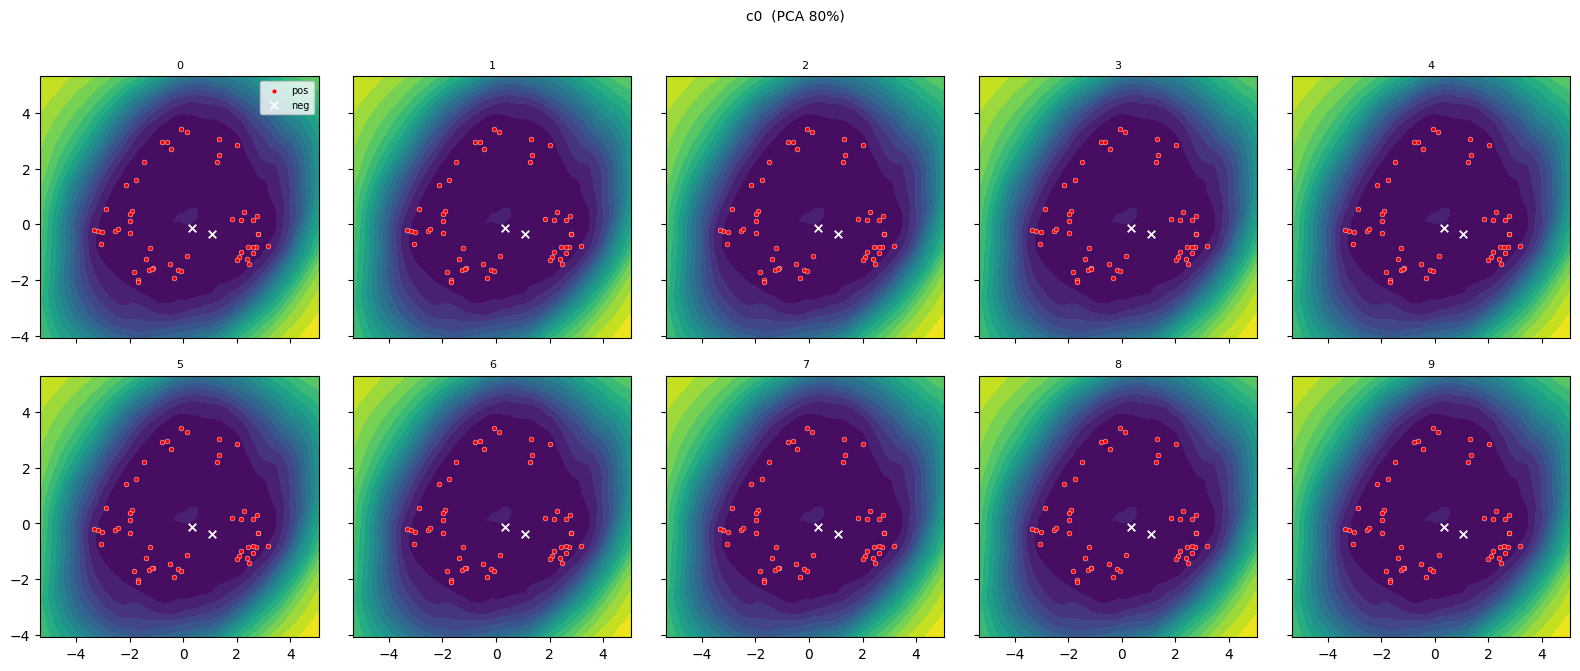

[20260417_201751_Distance_EBM/c1] K=10 grid=(54, 52) in 42.1s
  saved: experiments/ebms/20260417_201751_Distance_EBM/heatmap_members_c1.png


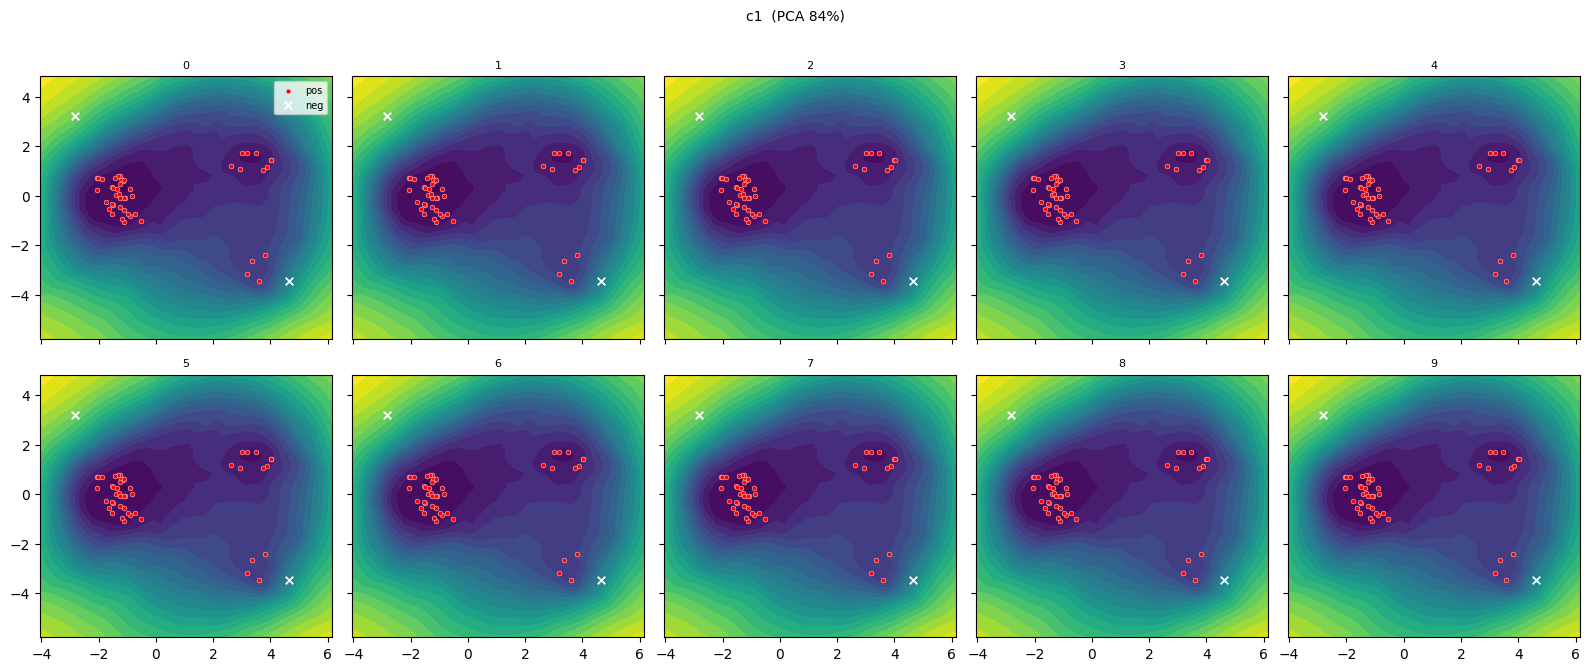

In [7]:
heatmap_info = {}
for c in CLASSES:
    label = f'c{c}'
    heatmap_info[label] = compute_heatmap_grid(ENSEMBLE_ROOT / label, gpu=GPUS[0])
    plot_ebm_map_from_info(heatmap_info[label], label,
                            save_path=ENSEMBLE_ROOT / f'heatmap_members_{label}.png')


## 5. Variance + Mean heatmap — MC Σ̂ (위: std, 아래: mean)

In [6]:
def plot_var_mean_grid(conds_info, cmap_std='magma', cmap_mean='viridis', save_path=None):
    panels = []
    for label, info in conds_info.items():
        E_stack = np.stack(info['all_E'], axis=0)
        K_ = E_stack.shape[0]
        E_std  = np.std(E_stack, axis=0, ddof=1 if K_ > 1 else 0)
        E_mean = np.mean(E_stack, axis=0)
        Z_negs_all = (np.vstack([z for z in info.get('Z_negs', []) if z is not None and len(z)])
                      if info.get('Z_negs') else np.zeros((0, 2)))
        panels.append((label, info['ZZ1'], info['ZZ2'], E_std, E_mean,
                       info['Z_class'], Z_negs_all, K_))
    std_vmax  = max(p[3].max() for p in panels)
    mean_vmin = min(p[4].min() for p in panels)
    mean_vmax = max(p[4].max() for p in panels)
    fig, axes = plt.subplots(2, len(panels), figsize=(4*len(panels), 7.4), squeeze=False)
    for col, (label, ZZ1, ZZ2, E_std, E_mean, Z_class, Z_negs_all, K_) in enumerate(panels):
        x0, x1 = ZZ1.min(), ZZ1.max(); y0, y1 = ZZ2.min(), ZZ2.max()

        ax_s = axes[0, col]
        cs_s = ax_s.contourf(ZZ1, ZZ2, E_std, levels=20, cmap=cmap_std, vmin=0, vmax=std_vmax)
        ax_s.scatter(Z_class[:,0], Z_class[:,1], c='cyan', edgecolor='black', s=12, linewidth=0.3,
                     label='pos')
        if len(Z_negs_all):
            ax_s.scatter(Z_negs_all[:,0], Z_negs_all[:,1], c='white', marker='x', s=25,
                         linewidths=1.2, label='neg (∪ K)')
        ax_s.set_xlim(x0, x1); ax_s.set_ylim(y0, y1)
        ax_s.set_title(f'{label} std  (K={K_})', fontsize=9)
        ax_s.legend(loc='upper right', fontsize=7, framealpha=0.8)
        plt.colorbar(cs_s, ax=ax_s, shrink=0.85)

        ax_m = axes[1, col]
        cs_m = ax_m.contourf(ZZ1, ZZ2, E_mean, levels=20, cmap=cmap_mean, vmin=mean_vmin, vmax=mean_vmax)
        ax_m.scatter(Z_class[:,0], Z_class[:,1], c='red', edgecolor='white', s=12, linewidth=0.3,
                     label='pos')
        if len(Z_negs_all):
            ax_m.scatter(Z_negs_all[:,0], Z_negs_all[:,1], c='white', marker='x', s=25,
                         linewidths=1.2, label='neg (∪ K)')
        ax_m.set_xlim(x0, x1); ax_m.set_ylim(y0, y1)
        ax_m.set_title(f'{label} mean (K={K_})', fontsize=9)
        ax_m.legend(loc='upper right', fontsize=7, framealpha=0.8)
        plt.colorbar(cs_m, ax=ax_m, shrink=0.85)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f'  saved: {save_path}')
    plt.show()
    return {p[0]: {'std': p[3], 'mean': p[4]} for p in panels}

stats_maps = plot_var_mean_grid(heatmap_info,
                                 save_path=ENSEMBLE_ROOT / 'heatmap_std_mean.png')
std_maps   = {lbl: s['std']  for lbl, s in stats_maps.items()}
mean_maps  = {lbl: s['mean'] for lbl, s in stats_maps.items()}


NameError: name 'heatmap_info' is not defined

## 6. Summary

In [18]:
rows = [{'class': lbl, 'K': K,
         'std_median': float(np.median(S)),
         'std_q90':    float(np.quantile(S, 0.9)),
         'std_max':    float(S.max())}
        for lbl, S in std_maps.items()]
pd.DataFrame(rows)

,class,K,std_median,std_q90,std_max
0,c0,10,0.1676,0.2605,0.3539
1,c1,10,0.1638,0.2429,0.4056


## 7. 이전 run 의 heatmap 재시각화

아래 `VIEW_ENSEMBLE_ROOT` 에 `experiments/ebms/...._EBM` 경로를 넣으면
해당 run 의 c{class} 폴더를 스캔해 per-member / std+mean heatmap 을 다시 그리고
같은 폴더에 PNG 로 저장함. 캐시(`heatmap_pad*_h*.npz`) 있으면 재사용 → 빠름.

In [19]:
# --- 이전 run 경로 입력 ---------------------------------------------------
VIEW_ENSEMBLE_ROOT = ''   # 예: 'experiments/ebms/20260415_101520_Subsample-Distance_EBM'
# -------------------------------------------------------------------------

view_root = Path(VIEW_ENSEMBLE_ROOT)
assert VIEW_ENSEMBLE_ROOT, 'VIEW_ENSEMBLE_ROOT 에 경로를 넣어주세요.'
assert view_root.exists(), f'경로 없음: {view_root}'

view_classes = sorted(
    int(p.name[1:]) for p in view_root.iterdir()
    if p.is_dir() and p.name.startswith('c') and p.name[1:].isdigit()
)
assert view_classes, f'c{{class}} 하위 폴더 없음: {view_root}'
print(f'Viewing: {view_root}  classes={view_classes}')

view_info = {}
for c in view_classes:
    label = f'c{c}'
    view_info[label] = compute_heatmap_grid(view_root / label, gpu=GPUS[0])
    plot_ebm_map_from_info(
        view_info[label], f'{label}  —  {view_root.name}',
        save_path=view_root / f'heatmap_members_{label}.png',
    )

view_stats = plot_var_mean_grid(
    view_info,
    save_path=view_root / 'heatmap_std_mean.png',
)

pd.DataFrame([
    {'class': lbl, 'K': len(view_info[lbl]['all_E']),
     'std_median': float(np.median(s['std'])),
     'std_q90':    float(np.quantile(s['std'], 0.9)),
     'std_max':    float(s['std'].max()),
     'mean_median': float(np.median(s['mean']))}
    for lbl, s in view_stats.items()
])


AssertionError: VIEW_ENSEMBLE_ROOT 에 경로를 넣어주세요.

## 8. Next steps

- **nb 02**: `ENSEMBLE_ROOT` 위 출력값 복붙 → VP-SGLD hyperparameter sweep
- **nb 03**: nb 02 가 저장한 `sweep_top.json` 자동 로드 → baseline 비교
- 더 다양한 ensemble 보려면: `METHODS_ACTIVE` / `K` / `DATASET` 바꿔서 이 노트북 재실행 (새 timestamped run)